# 05 - Análisis Profundo de Correlaciones

**Pregunta de negocio:** ¿Qué relaciones entre variables son reales vs espurias?

## Objetivos
- Comparar correlación de Pearson vs Spearman y entender cuándo usar cada una
- Evaluar significancia estadística de las correlaciones (p-values + corrección de Bonferroni)
- Usar correlaciones parciales para controlar variables confusoras
- Identificar la paradoja de Simpson en nuestros datos
- Distinguir correlaciones espurias de relaciones genuinas

## Teoría

### Pearson vs Spearman
- **Pearson (r)**: mide relación *lineal* entre dos variables continuas. Sensible a outliers.
  - r = Cov(X,Y) / (σ_X · σ_Y)
- **Spearman (ρ)**: mide relación *monótona* (no necesariamente lineal). Basado en rangos.
  - Se aplica Pearson a los rangos de los datos
- Si Pearson ≈ Spearman → relación lineal
- Si Spearman >> Pearson → relación no lineal (ej. logarítmica, exponencial)

### Correlación ≠ Causalidad
- Dos variables pueden correlacionarse por:
  1. **Causalidad directa**: X → Y
  2. **Causalidad inversa**: Y → X
  3. **Variable confusora**: Z → X y Z → Y (correlación espuria)
  4. **Coincidencia**: correlación por azar (especialmente con muchas comparaciones)

### Correlación Parcial
- Mide la correlación entre X e Y *controlando* por Z
- Se obtiene correlacionando los residuos de regresionar X~Z e Y~Z
- Si la correlación parcial desaparece → Z era confusora

### Paradoja de Simpson
- Una tendencia que aparece en los datos agregados puede *invertirse* al estratificar por grupos
- Muy común cuando los subgrupos tienen tamaños y medias diferentes

### Significancia y comparaciones múltiples
- Con α=0.05 y 100 comparaciones, esperamos ~5 falsos positivos
- **Corrección de Bonferroni**: α_ajustado = α / n_comparaciones
- Más conservadora pero protege contra falsos positivos

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data/raw")
processed_dir = os.path.join(project_root, "data/processed")
rng = np.random.default_rng(42)

vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga de datos

In [2]:
# Cargar telemetría y agregar por viaje
files = sorted(glob.glob(os.path.join(data_dir, "telemetry/telemetry_*.csv")))
telemetry = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
fleet = pd.read_csv(os.path.join(data_dir, "fleet_profiles.csv"))
telemetry = telemetry.merge(fleet[['vehicle_id', 'vehicle_type']], on='vehicle_id', how='left')

# Agregar por viaje
trip_stats = telemetry.groupby('trip_id').agg(
    speed_mean=('speed_kmh', 'mean'),
    speed_max=('speed_kmh', 'max'),
    speed_std=('speed_kmh', 'std'),
    consumption_mean=('fuel_consumption_rate', 'mean'),
    battery_temp_mean=('battery_temp_c', 'mean'),
    battery_soc_mean=('battery_soc_pct', 'mean'),
    motor_rpm_mean=('motor_rpm', 'mean'),
    motor_power_mean=('motor_power_kw', 'mean'),
    acceleration_mean=('acceleration_ms2', 'mean'),
    acceleration_std=('acceleration_ms2', 'std'),
    battery_voltage_mean=('battery_voltage', 'mean'),
    battery_current_mean=('battery_current_a', 'mean'),
    vehicle_id=('vehicle_id', 'first'),
    vehicle_type=('vehicle_type', 'first'),
    road_type=('road_type', 'first'),
).reset_index()

# Cargar encuestas y datos fusionados
surveys = pd.read_csv(os.path.join(data_dir, "surveys/buyer_surveys.csv"))
merged = pd.read_csv(os.path.join(processed_dir, "vehicle_survey_merged.csv"))

print(f"Registros telemetría: {len(telemetry):,}")
print(f"Viajes agregados:     {len(trip_stats):,}")
print(f"Encuestas:            {len(surveys):,}")
print(f"Datos fusionados:     {len(merged):,}")
print(f"\nColumnas trip_stats: {list(trip_stats.columns)}")
print(f"\nColumnas merged:     {list(merged.columns)}")

Registros telemetría: 6,076,720
Viajes agregados:     3,234
Encuestas:            500
Datos fusionados:     50

Columnas trip_stats: ['trip_id', 'speed_mean', 'speed_max', 'speed_std', 'consumption_mean', 'battery_temp_mean', 'battery_soc_mean', 'motor_rpm_mean', 'motor_power_mean', 'acceleration_mean', 'acceleration_std', 'battery_voltage_mean', 'battery_current_mean', 'vehicle_id', 'vehicle_type', 'road_type']

Columnas merged:     ['vehicle_id', 'n_registros', 'n_viajes', 'speed_mean', 'speed_max', 'speed_std', 'consumption_mean', 'consumption_total', 'battery_soc_mean', 'battery_temp_max', 'motor_rpm_mean', 'motor_power_mean', 'harsh_braking_count', 'estimated_km', 'vehicle_type', 'fuel_type', 'model_year', 'motor_power_kw', 'max_speed_kmh', 'weight_kg', 'battery_capacity_kwh', 'tank_capacity_l', 'base_consumption_city', 'base_consumption_highway', 'co2_emissions_gkm', 'age', 'gender', 'income_bracket', 'purchase_reason', 'expected_usage', 'driving_style', 'satisfaction_score', 'wo

## 2. Matriz de correlación: Pearson vs Spearman

Calculamos ambas matrices para las variables numéricas clave de telemetría y las comparamos lado a lado.

- Si ambas coinciden → relación lineal
- Si difieren → relación no lineal o presencia de outliers

In [3]:
# Variables clave para correlación
corr_vars = ['speed_mean', 'speed_max', 'speed_std', 'consumption_mean',
             'battery_temp_mean', 'battery_soc_mean', 'motor_rpm_mean',
             'motor_power_mean', 'acceleration_mean', 'acceleration_std',
             'battery_voltage_mean', 'battery_current_mean']

# Etiquetas legibles en español
labels = ['Vel. media', 'Vel. máx', 'Vel. σ', 'Consumo',
          'Temp. batería', 'SOC batería', 'RPM motor',
          'Potencia motor', 'Acel. media', 'Acel. σ',
          'Voltaje bat.', 'Corriente bat.']

data_corr = trip_stats[corr_vars].dropna()

pearson_corr = data_corr.corr(method='pearson')
spearman_corr = data_corr.corr(method='spearman')

print(f"Variables analizadas: {len(corr_vars)}")
print(f"Observaciones (viajes): {len(data_corr):,}")
print(f"Pares de correlación: {len(corr_vars) * (len(corr_vars)-1) // 2}")

Variables analizadas: 12
Observaciones (viajes): 1,674
Pares de correlación: 66


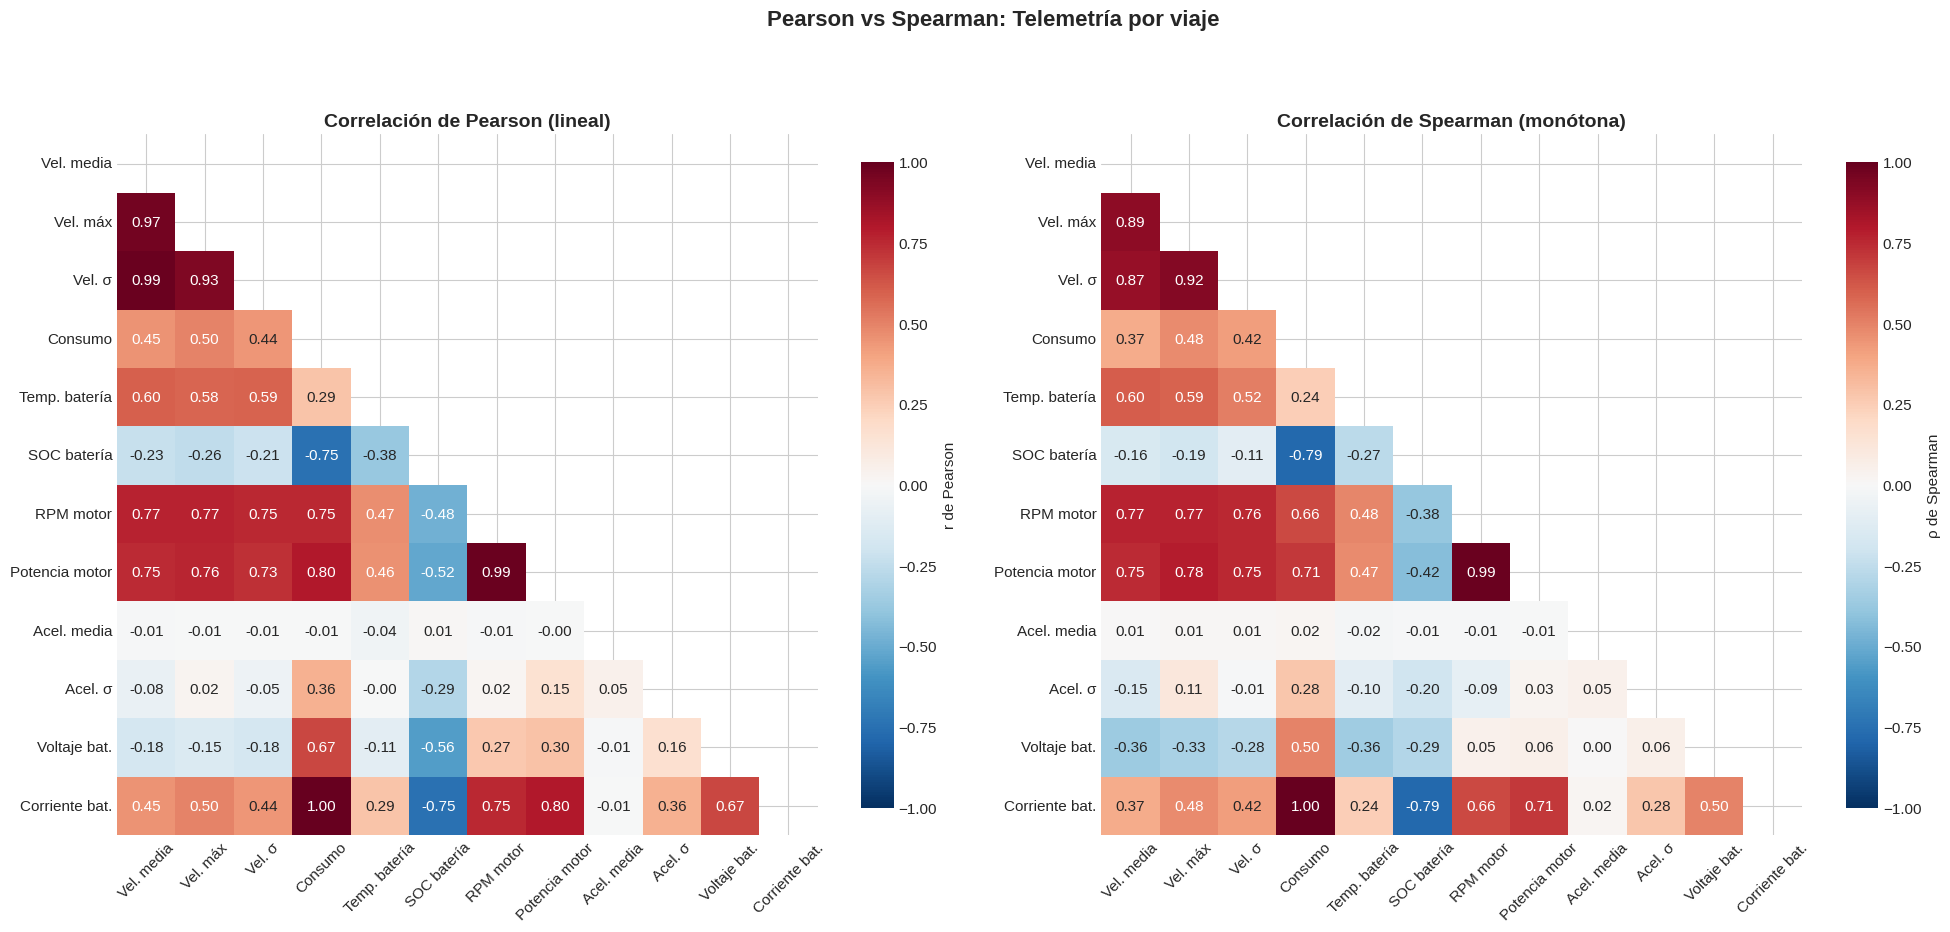

In [4]:
# Heatmaps triangulares lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

# Pearson
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=axes[0],
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'shrink': 0.8, 'label': 'r de Pearson'})
axes[0].set_title('Correlación de Pearson (lineal)', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Spearman
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=axes[1],
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'shrink': 0.8, 'label': 'ρ de Spearman'})
axes[1].set_title('Correlación de Spearman (monótona)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Pearson vs Spearman: Telemetría por viaje', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

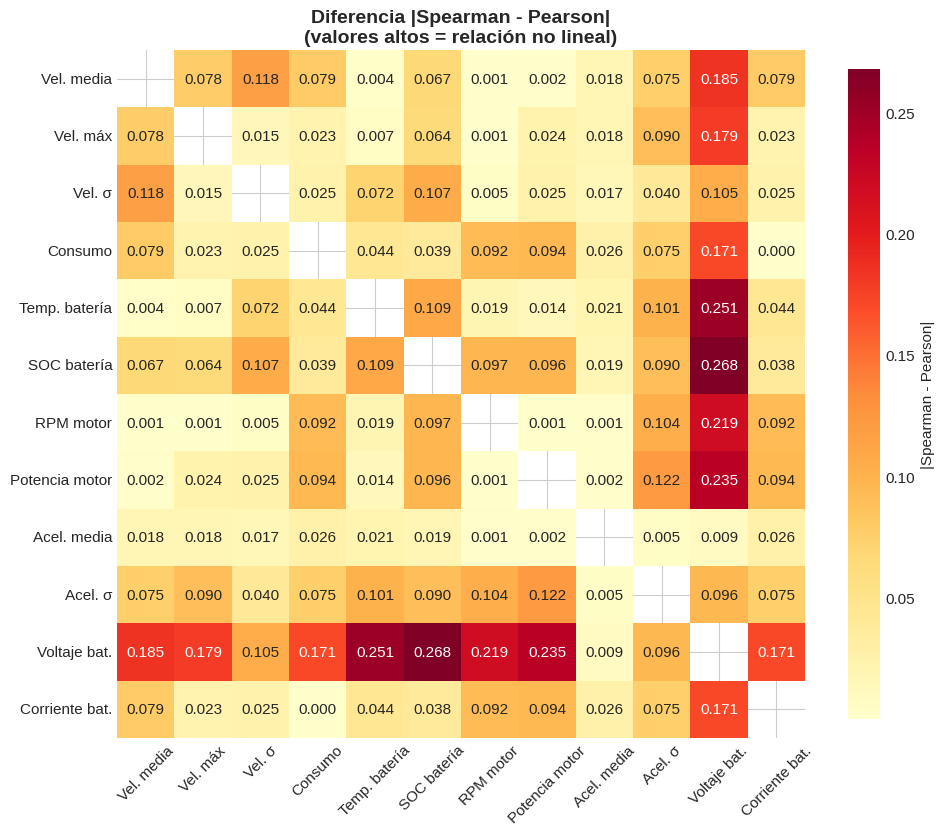

Top 10 pares donde Pearson y Spearman más difieren (posibles relaciones NO lineales):


,Variable 1,Variable 2,Pearson,Spearman,|Diferencia|
49,SOC batería,Voltaje bat.,-0.5592,-0.2913,0.2679
43,Temp. batería,Voltaje bat.,-0.1066,-0.3578,0.2512
58,Potencia motor,Voltaje bat.,0.2966,0.0614,0.2352
54,RPM motor,Voltaje bat.,0.2734,0.0540,0.2194
9,Vel. media,Voltaje bat.,-0.1762,-0.3608,0.1846
19,Vel. máx,Voltaje bat.,-0.1471,-0.3262,0.1791
36,Consumo,Voltaje bat.,0.6678,0.4969,0.1709
65,Voltaje bat.,Corriente bat.,0.6680,0.4972,0.1708
57,Potencia motor,Acel. σ,0.1491,0.0268,0.1223
1,Vel. media,Vel. σ,0.9876,0.8696,0.1180


In [5]:
# Heatmap de la diferencia: dónde Pearson y Spearman no coinciden
diff = (spearman_corr - pearson_corr).abs()

fig, ax = plt.subplots(figsize=(10, 9))
mask_diag = np.eye(len(corr_vars), dtype=bool)
sns.heatmap(diff, mask=mask_diag, annot=True, fmt='.3f', cmap='YlOrRd',
            square=True, ax=ax, xticklabels=labels, yticklabels=labels,
            cbar_kws={'shrink': 0.8, 'label': '|Spearman - Pearson|'})
ax.set_title('Diferencia |Spearman - Pearson|\n(valores altos = relación no lineal)',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Pares con mayor diferencia
diff_pairs = []
for i, v1 in enumerate(corr_vars):
    for j, v2 in enumerate(corr_vars):
        if i < j:
            diff_pairs.append({
                'Variable 1': labels[i], 'Variable 2': labels[j],
                'Pearson': pearson_corr.iloc[i, j],
                'Spearman': spearman_corr.iloc[i, j],
                '|Diferencia|': abs(spearman_corr.iloc[i, j] - pearson_corr.iloc[i, j])
            })

diff_df = pd.DataFrame(diff_pairs).sort_values('|Diferencia|', ascending=False)
print("Top 10 pares donde Pearson y Spearman más difieren (posibles relaciones NO lineales):")
diff_df.head(10).round(4)

**Interpretación:**
- Las celdas con diferencia alta (>0.05) sugieren relaciones no lineales entre esas variables
- Para esos pares, Pearson subestima la relación real
- Las variables de batería suelen tener relaciones no lineales (curvas de carga/descarga)

## 3. Significancia estadística de las correlaciones

No basta con que una correlación sea alta: necesitamos verificar que no sea producto del azar.
Para cada par calculamos el p-value con `scipy.stats.pearsonr` y `spearmanr`.

In [6]:
# Calcular correlaciones con p-values para todos los pares
results = []
n_comparisons = len(corr_vars) * (len(corr_vars) - 1) // 2
bonferroni_alpha = 0.05 / n_comparisons

for i, v1 in enumerate(corr_vars):
    for j, v2 in enumerate(corr_vars):
        if i < j:
            x = data_corr[v1].values
            y = data_corr[v2].values
            
            r_p, p_p = stats.pearsonr(x, y)
            r_s, p_s = stats.spearmanr(x, y)
            
            # Estrellas de significancia
            if p_p < 0.001:
                sig = '***'
            elif p_p < 0.01:
                sig = '**'
            elif p_p < 0.05:
                sig = '*'
            else:
                sig = 'ns'
            
            bonf_sig = 'Sí' if p_p < bonferroni_alpha else 'No'
            
            results.append({
                'Var 1': labels[i], 'Var 2': labels[j],
                'Pearson r': r_p, 'p-value (P)': p_p,
                'Spearman ρ': r_s, 'p-value (S)': p_s,
                'Sig.': sig, 'Bonferroni': bonf_sig
            })

sig_df = pd.DataFrame(results)
sig_df['|Pearson r|'] = sig_df['Pearson r'].abs()
sig_df = sig_df.sort_values('|Pearson r|', ascending=False)

print(f"Total de comparaciones: {n_comparisons}")
print(f"α original: 0.05")
print(f"α Bonferroni: {bonferroni_alpha:.6f}")
print(f"\nCorrelaciones significativas (p < 0.05): {(sig_df['Sig.'] != 'ns').sum()}")
print(f"Correlaciones significativas (Bonferroni): {(sig_df['Bonferroni'] == 'Sí').sum()}")
print(f"\nTop 15 correlaciones más fuertes:")
sig_df[['Var 1', 'Var 2', 'Pearson r', 'p-value (P)', 'Spearman ρ', 'Sig.', 'Bonferroni']].head(15).round(4)

Total de comparaciones: 66
α original: 0.05
α Bonferroni: 0.000758

Correlaciones significativas (p < 0.05): 53
Correlaciones significativas (Bonferroni): 50

Top 15 correlaciones más fuertes:


,Var 1,Var 2,Pearson r,p-value (P),Spearman ρ,Sig.,Bonferroni
37,Consumo,Corriente bat.,1.0000,0.0,1.0000,***,Sí
51,RPM motor,Potencia motor,0.9896,0.0,0.9903,***,Sí
1,Vel. media,Vel. σ,0.9876,0.0,0.8696,***,Sí
0,Vel. media,Vel. máx,0.9685,0.0,0.8907,***,Sí
11,Vel. máx,Vel. σ,0.9344,0.0,0.9195,***,Sí
33,Consumo,Potencia motor,0.8017,0.0,0.7074,***,Sí
59,Potencia motor,Corriente bat.,0.8015,0.0,0.7072,***,Sí
5,Vel. media,RPM motor,0.7690,0.0,0.7685,***,Sí
15,Vel. máx,RPM motor,0.7662,0.0,0.7672,***,Sí
16,Vel. máx,Potencia motor,0.7588,0.0,0.7825,***,Sí


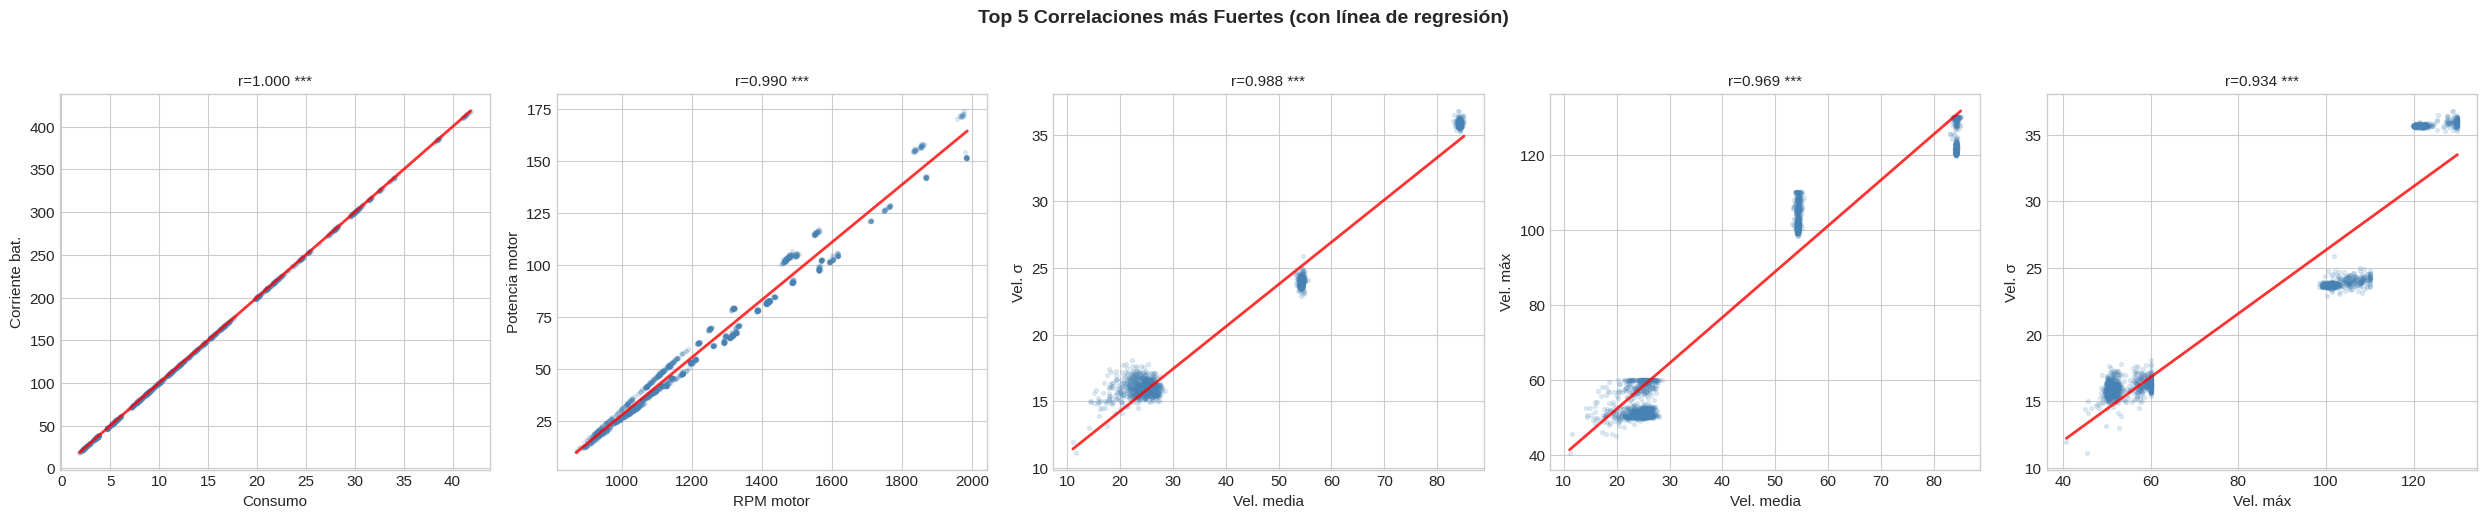

→ Las correlaciones marcadas con *** son altamente significativas (p < 0.001)
→ Pero significancia ≠ importancia: con muchos datos, hasta correlaciones pequeñas son significativas


In [7]:
# Visualizar: scatter plot de las 5 correlaciones más fuertes con línea de regresión
top5 = sig_df.head(5)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (_, row) in zip(axes, top5.iterrows()):
    # Recuperar nombres originales de variables
    idx1 = labels.index(row['Var 1'])
    idx2 = labels.index(row['Var 2'])
    v1 = corr_vars[idx1]
    v2 = corr_vars[idx2]
    
    x = data_corr[v1]
    y = data_corr[v2]
    
    ax.scatter(x, y, alpha=0.15, s=8, color='steelblue')
    
    # Línea de regresión
    z = np.polyfit(x, y, 1)
    p_line = np.poly1d(z)
    x_sorted = np.sort(x)
    ax.plot(x_sorted, p_line(x_sorted), 'r-', linewidth=2, alpha=0.8)
    
    ax.set_xlabel(row['Var 1'])
    ax.set_ylabel(row['Var 2'])
    ax.set_title(f"r={row['Pearson r']:.3f} {row['Sig.']}", fontsize=11)

plt.suptitle('Top 5 Correlaciones más Fuertes (con línea de regresión)', 
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("→ Las correlaciones marcadas con *** son altamente significativas (p < 0.001)")
print("→ Pero significancia ≠ importancia: con muchos datos, hasta correlaciones pequeñas son significativas")

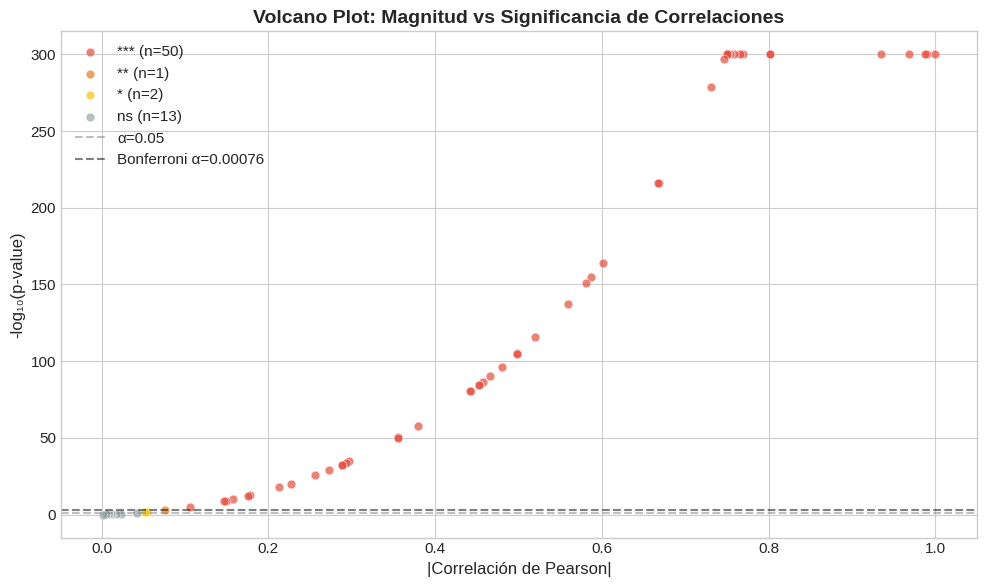

→ Arriba-derecha: correlaciones fuertes Y significativas (las más confiables)
→ Arriba-izquierda: significativas pero débiles (cuidado: puede ser por n grande)
→ Abajo: no significativas


In [8]:
# Visualizar significancia vs magnitud
fig, ax = plt.subplots(figsize=(10, 6))

colors_sig = {'***': '#e74c3c', '**': '#e67e22', '*': '#f1c40f', 'ns': '#95a5a6'}
for sig_level in ['***', '**', '*', 'ns']:
    subset = sig_df[sig_df['Sig.'] == sig_level]
    ax.scatter(subset['|Pearson r|'], -np.log10(subset['p-value (P)'].clip(lower=1e-300)),
              c=colors_sig[sig_level], label=f'{sig_level} (n={len(subset)})',
              alpha=0.7, s=40, edgecolors='white', linewidth=0.5)

ax.axhline(-np.log10(0.05), color='gray', linestyle='--', alpha=0.5, label='α=0.05')
ax.axhline(-np.log10(bonferroni_alpha), color='black', linestyle='--', alpha=0.5, 
           label=f'Bonferroni α={bonferroni_alpha:.5f}')
ax.set_xlabel('|Correlación de Pearson|', fontsize=12)
ax.set_ylabel('-log₁₀(p-value)', fontsize=12)
ax.set_title('Volcano Plot: Magnitud vs Significancia de Correlaciones', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print("→ Arriba-derecha: correlaciones fuertes Y significativas (las más confiables)")
print("→ Arriba-izquierda: significativas pero débiles (cuidado: puede ser por n grande)")
print("→ Abajo: no significativas")

**Problema de comparaciones múltiples:**
- Con 66 comparaciones y α=0.05, esperaríamos ~3 falsos positivos por azar
- La corrección de Bonferroni es conservadora: divide α entre el número de comparaciones
- Solo las correlaciones que sobreviven Bonferroni son robustas contra falsos positivos

## 4. Correlaciones parciales: controlando por tipo de vehículo

La correlación entre velocidad y consumo puede estar inflada (o deflada) por el tipo de vehículo:
los deportivos van más rápido Y consumen más, creando una correlación "confundida".

**Correlación parcial** = correlación entre los residuos después de eliminar el efecto del confusor.

### Método manual:
1. Crear dummies para vehicle_type
2. Regresionar X ~ dummies → obtener residuos de X
3. Regresionar Y ~ dummies → obtener residuos de Y
4. Correlacionar los residuos → correlación parcial

In [9]:
def partial_correlation(df, x_col, y_col, confound_col):
    """
    Calcula la correlación parcial entre x_col e y_col,
    controlando por confound_col (variable categórica).
    
    Método: correlación de residuos tras regresionar el confusor.
    """
    # Crear dummies para el confusor
    dummies = pd.get_dummies(df[confound_col], drop_first=True).values
    
    x = df[x_col].values.reshape(-1, 1)
    y = df[y_col].values.reshape(-1, 1)
    
    # Regresionar X ~ confusor
    reg_x = LinearRegression().fit(dummies, x)
    residuals_x = x.ravel() - reg_x.predict(dummies).ravel()
    
    # Regresionar Y ~ confusor
    reg_y = LinearRegression().fit(dummies, y)
    residuals_y = y.ravel() - reg_y.predict(dummies).ravel()
    
    # Correlación de los residuos
    r, p = stats.pearsonr(residuals_x, residuals_y)
    return r, p, residuals_x, residuals_y


# Pares de variables para correlación parcial
pairs = [
    ('speed_mean', 'consumption_mean', 'Velocidad → Consumo'),
    ('motor_rpm_mean', 'consumption_mean', 'RPM motor → Consumo'),
    ('speed_mean', 'battery_temp_mean', 'Velocidad → Temp. batería'),
    ('motor_power_mean', 'consumption_mean', 'Potencia → Consumo'),
    ('acceleration_std', 'consumption_mean', 'Variabilidad acel. → Consumo'),
]

clean = trip_stats.dropna(subset=['speed_mean', 'consumption_mean', 'battery_temp_mean',
                                  'motor_rpm_mean', 'motor_power_mean', 'acceleration_std',
                                  'vehicle_type'])

partial_results = []
for x_col, y_col, label in pairs:
    # Correlación bruta
    r_raw, p_raw = stats.pearsonr(clean[x_col], clean[y_col])
    # Correlación parcial
    r_partial, p_partial, _, _ = partial_correlation(clean, x_col, y_col, 'vehicle_type')
    
    partial_results.append({
        'Relación': label,
        'r bruto': r_raw,
        'p bruto': p_raw,
        'r parcial': r_partial,
        'p parcial': p_partial,
        'Cambio': f"{((r_partial - r_raw) / abs(r_raw)) * 100:+.1f}%" if abs(r_raw) > 0.001 else 'N/A'
    })

partial_df = pd.DataFrame(partial_results)
print("Correlaciones brutas vs parciales (controlando por tipo de vehículo):")
partial_df.round(4)

Correlaciones brutas vs parciales (controlando por tipo de vehículo):


,Relación,r bruto,p bruto,r parcial,p parcial,Cambio
0,Velocidad → Consumo,0.3913,0.0,0.7019,0.0,+79.4%
1,RPM motor → Consumo,0.7104,0.0,0.7327,0.0,+3.1%
2,Velocidad → Temp. batería,0.6000,0.0,0.5947,0.0,-0.9%
3,Potencia → Consumo,0.7513,0.0,0.7815,0.0,+4.0%
4,Variabilidad acel. → Consumo,0.2362,0.0,0.3310,0.0,+40.1%


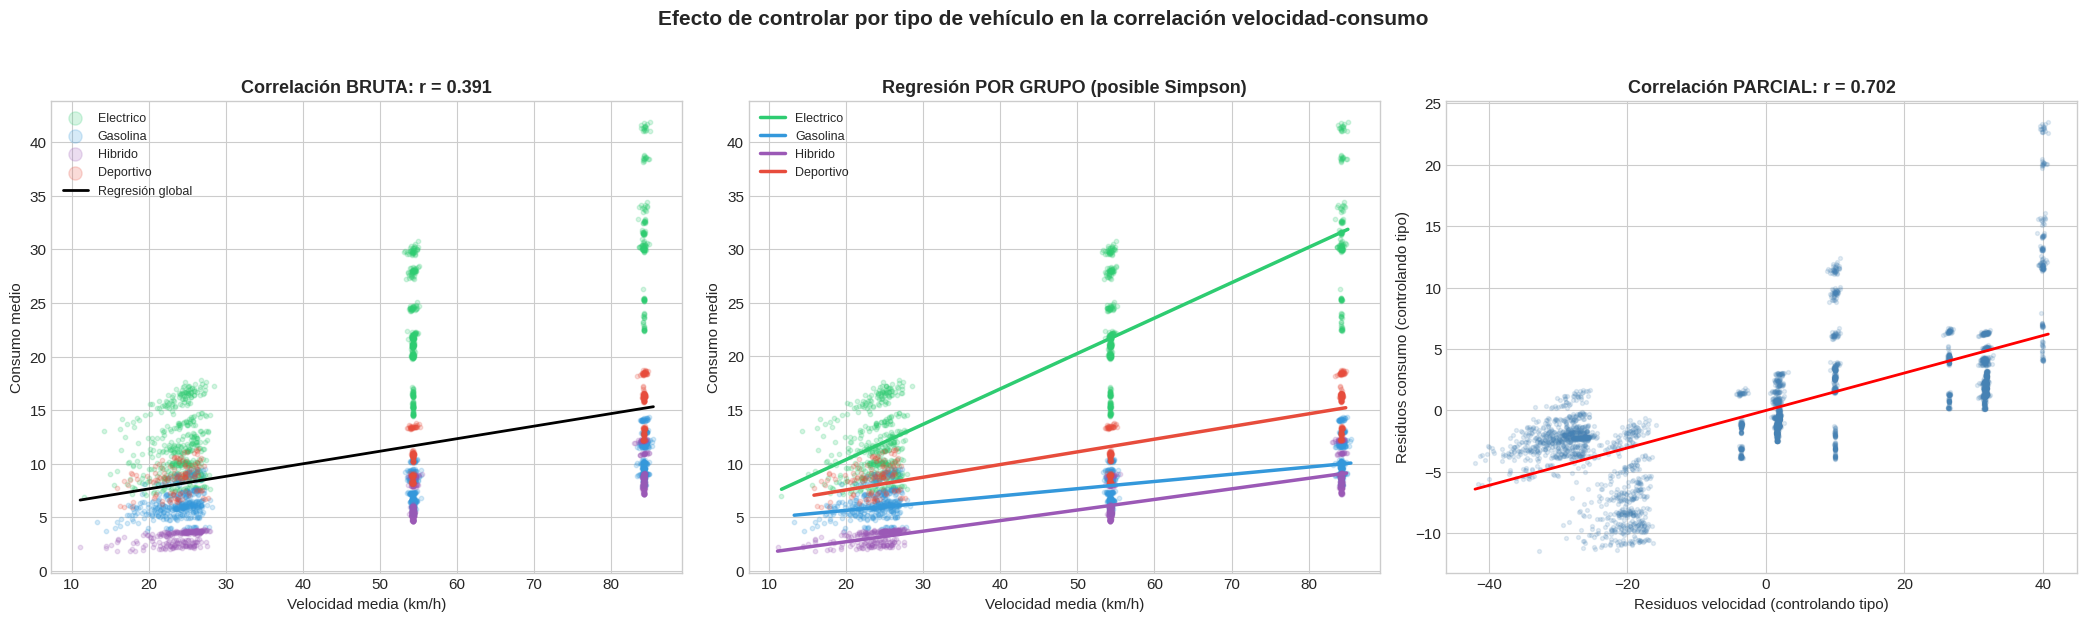

→ Correlación bruta (sin controlar):     r = 0.3913
→ Correlación parcial (controlando tipo): r = 0.7019
→ Cambio: +79.4%

Si la correlación parcial es MUY diferente de la bruta:
  → el tipo de vehículo era un confusor importante
Si son similares:
  → la relación velocidad-consumo es genuina (no confundida por el tipo)


In [10]:
# Visualización: antes y después de controlar por tipo de vehículo
# Caso principal: velocidad vs consumo

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1. Scatter bruto coloreado por tipo
ax = axes[0]
for vtype, color in vtype_colors.items():
    subset = clean[clean['vehicle_type'] == vtype]
    ax.scatter(subset['speed_mean'], subset['consumption_mean'], 
              alpha=0.2, s=10, c=color, label=vtype.capitalize())

# Línea de regresión global
z = np.polyfit(clean['speed_mean'], clean['consumption_mean'], 1)
x_line = np.linspace(clean['speed_mean'].min(), clean['speed_mean'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), 'k-', linewidth=2, label='Regresión global')

r_raw, _ = stats.pearsonr(clean['speed_mean'], clean['consumption_mean'])
ax.set_xlabel('Velocidad media (km/h)')
ax.set_ylabel('Consumo medio')
ax.set_title(f'Correlación BRUTA: r = {r_raw:.3f}', fontsize=13, fontweight='bold')
ax.legend(markerscale=3, fontsize=9)

# 2. Scatter con regresión por grupo (Simpson)
ax = axes[1]
for vtype, color in vtype_colors.items():
    subset = clean[clean['vehicle_type'] == vtype]
    ax.scatter(subset['speed_mean'], subset['consumption_mean'], 
              alpha=0.2, s=10, c=color)
    # Regresión por grupo
    if len(subset) > 10:
        z_g = np.polyfit(subset['speed_mean'], subset['consumption_mean'], 1)
        x_g = np.linspace(subset['speed_mean'].min(), subset['speed_mean'].max(), 100)
        ax.plot(x_g, np.poly1d(z_g)(x_g), color=color, linewidth=2.5, 
               label=f'{vtype.capitalize()}')

ax.set_xlabel('Velocidad media (km/h)')
ax.set_ylabel('Consumo medio')
ax.set_title('Regresión POR GRUPO (posible Simpson)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# 3. Residuos (correlación parcial)
ax = axes[2]
r_partial, _, res_x, res_y = partial_correlation(clean, 'speed_mean', 'consumption_mean', 'vehicle_type')

ax.scatter(res_x, res_y, alpha=0.15, s=8, color='steelblue')
z_r = np.polyfit(res_x, res_y, 1)
x_r = np.linspace(res_x.min(), res_x.max(), 100)
ax.plot(x_r, np.poly1d(z_r)(x_r), 'r-', linewidth=2)

ax.set_xlabel('Residuos velocidad (controlando tipo)')
ax.set_ylabel('Residuos consumo (controlando tipo)')
ax.set_title(f'Correlación PARCIAL: r = {r_partial:.3f}', fontsize=13, fontweight='bold')

plt.suptitle('Efecto de controlar por tipo de vehículo en la correlación velocidad-consumo',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"→ Correlación bruta (sin controlar):     r = {r_raw:.4f}")
print(f"→ Correlación parcial (controlando tipo): r = {r_partial:.4f}")
print(f"→ Cambio: {((r_partial - r_raw) / abs(r_raw)) * 100:+.1f}%")
print("")
print("Si la correlación parcial es MUY diferente de la bruta:")
print("  → el tipo de vehículo era un confusor importante")
print("Si son similares:")
print("  → la relación velocidad-consumo es genuina (no confundida por el tipo)")

### Paradoja de Simpson: ejemplo concreto

La paradoja de Simpson ocurre cuando una tendencia que se observa globalmente se *invierte* dentro de cada subgrupo. Veamos si existe en nuestros datos.

In [11]:
# Buscar paradoja de Simpson: comparar signo de correlación global vs por grupo
simpson_candidates = []

check_pairs = [
    ('speed_mean', 'consumption_mean'),
    ('motor_rpm_mean', 'consumption_mean'),
    ('speed_mean', 'battery_temp_mean'),
    ('motor_power_mean', 'battery_temp_mean'),
    ('acceleration_std', 'consumption_mean'),
    ('battery_soc_mean', 'consumption_mean'),
    ('speed_mean', 'motor_rpm_mean'),
    ('battery_voltage_mean', 'consumption_mean'),
]

print("Buscando paradoja de Simpson (signo global ≠ signo en subgrupos):\n")
print(f"{'Par':<45} {'r global':>10} {'Eléctrico':>10} {'Gasolina':>10} {'Híbrido':>10} {'Deportivo':>10}")
print("-" * 95)

for v1, v2 in check_pairs:
    sub = clean[[v1, v2, 'vehicle_type']].dropna()
    r_global = sub[v1].corr(sub[v2])
    
    r_groups = {}
    for vtype in ['electrico', 'gasolina', 'hibrido', 'deportivo']:
        g = sub[sub['vehicle_type'] == vtype]
        r_groups[vtype] = g[v1].corr(g[v2]) if len(g) > 5 else np.nan
    
    # Verificar si hay inversión de signo
    signs_differ = any(np.sign(r) != np.sign(r_global) and not np.isnan(r) 
                       for r in r_groups.values())
    marker = " ← SIMPSON!" if signs_differ else ""
    
    label = f"{v1} vs {v2}"
    print(f"{label:<45} {r_global:>+10.3f} {r_groups.get('electrico', np.nan):>+10.3f} "
          f"{r_groups.get('gasolina', np.nan):>+10.3f} {r_groups.get('hibrido', np.nan):>+10.3f} "
          f"{r_groups.get('deportivo', np.nan):>+10.3f}{marker}")
    
    if signs_differ:
        simpson_candidates.append((v1, v2, r_global, r_groups))

print(f"\nCandidatos a paradoja de Simpson encontrados: {len(simpson_candidates)}")

Buscando paradoja de Simpson (signo global ≠ signo en subgrupos):

Par                                             r global  Eléctrico   Gasolina    Híbrido  Deportivo
-----------------------------------------------------------------------------------------------
speed_mean vs consumption_mean                    +0.391     +0.875     +0.722     +0.892     +0.826
motor_rpm_mean vs consumption_mean                +0.710     +0.852     +0.637     +0.667     +0.661
speed_mean vs battery_temp_mean                   +0.600     +0.582     +0.595     +0.613     +0.591
motor_power_mean vs battery_temp_mean             +0.410     +0.527     +0.494     +0.529     +0.508
acceleration_std vs consumption_mean              +0.236     +0.382     +0.498     +0.285     +0.311
battery_soc_mean vs consumption_mean              -0.750     -0.626       +nan     -0.083       +nan
speed_mean vs motor_rpm_mean                      +0.667     +0.901     +0.842     +0.844     +0.830
battery_voltage_mean vs consu

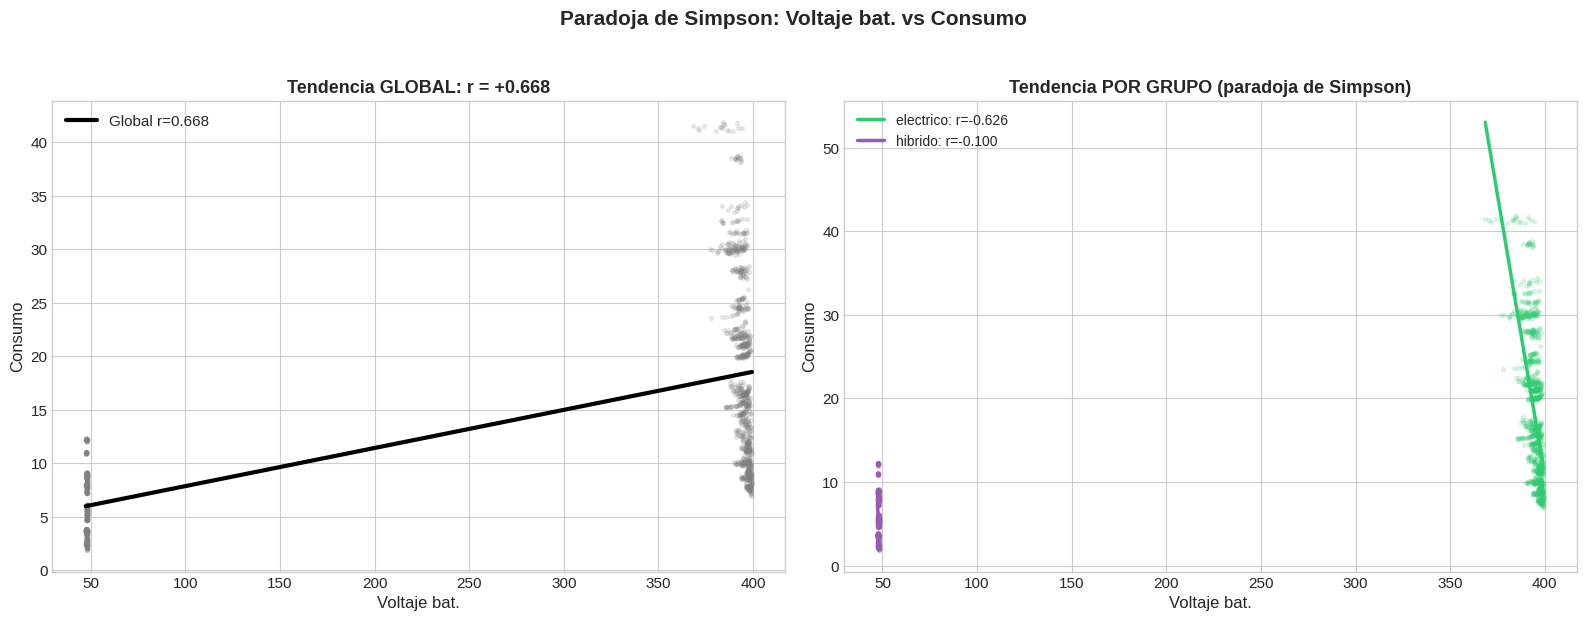

→ La tendencia global puede ser ENGAÑOSA si no se estratifica por subgrupos
→ Esto ocurre porque los subgrupos tienen medias y tamaños diferentes
→ Conclusión: SIEMPRE verificar si la correlación se mantiene dentro de cada grupo


In [12]:
# Visualizar el mejor caso de Simpson (o el primer candidato)
if simpson_candidates:
    v1, v2, r_global, r_groups = simpson_candidates[0]
    label1 = labels[corr_vars.index(v1)] if v1 in corr_vars else v1
    label2 = labels[corr_vars.index(v2)] if v2 in corr_vars else v2
else:
    # Si no hay paradoja clara, usar el par con mayor diferencia entre global y por grupo
    v1, v2 = 'speed_mean', 'consumption_mean'
    label1, label2 = 'Velocidad media', 'Consumo medio'
    r_global = clean[v1].corr(clean[v2])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: tendencia global
ax = axes[0]
sub = clean[[v1, v2]].dropna()
ax.scatter(sub[v1], sub[v2], alpha=0.15, s=8, color='gray')
z = np.polyfit(sub[v1], sub[v2], 1)
x_line = np.linspace(sub[v1].min(), sub[v1].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), 'k-', linewidth=3, label=f'Global r={r_global:.3f}')
ax.set_xlabel(label1, fontsize=12)
ax.set_ylabel(label2, fontsize=12)
ax.set_title(f'Tendencia GLOBAL: r = {r_global:+.3f}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# Panel 2: tendencia por grupo
ax = axes[1]
for vtype, color in vtype_colors.items():
    g = clean[clean['vehicle_type'] == vtype][[v1, v2]].dropna()
    if len(g) > 10:
        ax.scatter(g[v1], g[v2], alpha=0.15, s=8, c=color)
        z_g = np.polyfit(g[v1], g[v2], 1)
        x_g = np.linspace(g[v1].min(), g[v1].max(), 100)
        r_g = g[v1].corr(g[v2])
        ax.plot(x_g, np.poly1d(z_g)(x_g), color=color, linewidth=2.5,
               label=f'{vtype}: r={r_g:+.3f}')

ax.set_xlabel(label1, fontsize=12)
ax.set_ylabel(label2, fontsize=12)
ax.set_title('Tendencia POR GRUPO (paradoja de Simpson)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle(f'Paradoja de Simpson: {label1} vs {label2}',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("→ La tendencia global puede ser ENGAÑOSA si no se estratifica por subgrupos")
print("→ Esto ocurre porque los subgrupos tienen medias y tamaños diferentes")
print("→ Conclusión: SIEMPRE verificar si la correlación se mantiene dentro de cada grupo")

## 5. Correlaciones parciales: comparación visual

Veamos cómo cambian varias correlaciones al controlar por tipo de vehículo.

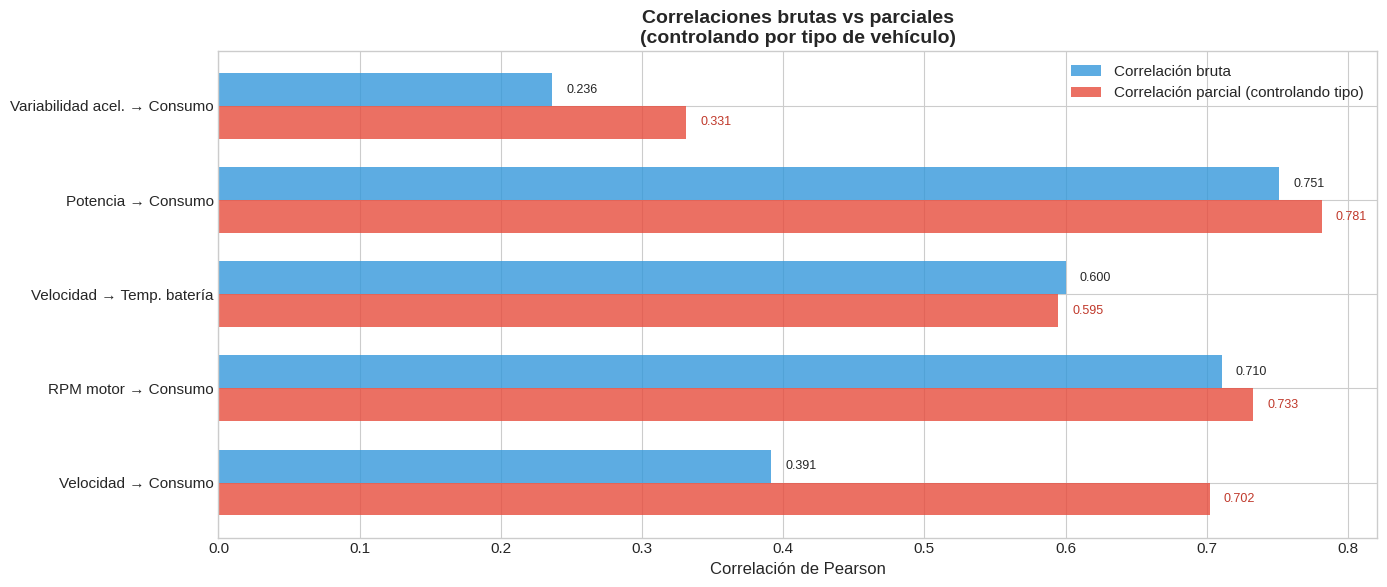

→ Si la barra roja es mucho más corta: el tipo de vehículo era confusor
→ Si ambas barras son similares: la relación es genuina, independiente del tipo


In [13]:
# Gráfico de barras: correlación bruta vs parcial para múltiples pares
fig, ax = plt.subplots(figsize=(14, 6))

y_pos = np.arange(len(partial_df))
bar_height = 0.35

bars1 = ax.barh(y_pos + bar_height/2, partial_df['r bruto'], bar_height, 
                label='Correlación bruta', color='#3498db', alpha=0.8)
bars2 = ax.barh(y_pos - bar_height/2, partial_df['r parcial'], bar_height,
                label='Correlación parcial (controlando tipo)', color='#e74c3c', alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(partial_df['Relación'], fontsize=11)
ax.set_xlabel('Correlación de Pearson', fontsize=12)
ax.set_title('Correlaciones brutas vs parciales\n(controlando por tipo de vehículo)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axvline(0, color='black', linewidth=0.5)

# Anotar valores
for i, (_, row) in enumerate(partial_df.iterrows()):
    ax.text(row['r bruto'] + 0.01 * np.sign(row['r bruto']), i + bar_height/2,
            f"{row['r bruto']:.3f}", va='center', fontsize=9)
    ax.text(row['r parcial'] + 0.01 * np.sign(row['r parcial']), i - bar_height/2,
            f"{row['r parcial']:.3f}", va='center', fontsize=9, color='#c0392b')

plt.tight_layout()
plt.show()

print("→ Si la barra roja es mucho más corta: el tipo de vehículo era confusor")
print("→ Si ambas barras son similares: la relación es genuina, independiente del tipo")

## 6. Correlaciones en datos de encuestas

Los datos de encuestas tienen variables de diferentes tipos:
- **Binarias** (would_recommend): usamos correlación **point-biserial** (caso especial de Pearson)
- **Ordinales** (satisfaction_score 1-5): usamos **Spearman** (basada en rangos)
- **Continuas** (km_driven, speed_mean, etc.): Pearson o Spearman

In [14]:
# Seleccionar variables numéricas del dataset fusionado
survey_tel_vars = []

# Variables de telemetría disponibles en merged
tel_candidates = ['speed_mean', 'speed_max', 'consumption_mean', 'battery_soc_mean',
                  'battery_temp_max', 'motor_rpm_mean', 'motor_power_mean', 'estimated_km']

# Variables de encuesta
survey_candidates = ['satisfaction_score', 'would_recommend', 'km_driven', 'age']

# Usar solo las que existen en merged
all_candidates = tel_candidates + survey_candidates
available_vars = [v for v in all_candidates if v in merged.columns]

print(f"Variables disponibles en merged: {available_vars}")

merged_numeric = merged[available_vars].dropna()
print(f"Observaciones completas: {len(merged_numeric)}")

Variables disponibles en merged: ['speed_mean', 'speed_max', 'consumption_mean', 'battery_soc_mean', 'battery_temp_max', 'motor_rpm_mean', 'motor_power_mean', 'estimated_km', 'satisfaction_score', 'would_recommend', 'km_driven', 'age']
Observaciones completas: 24


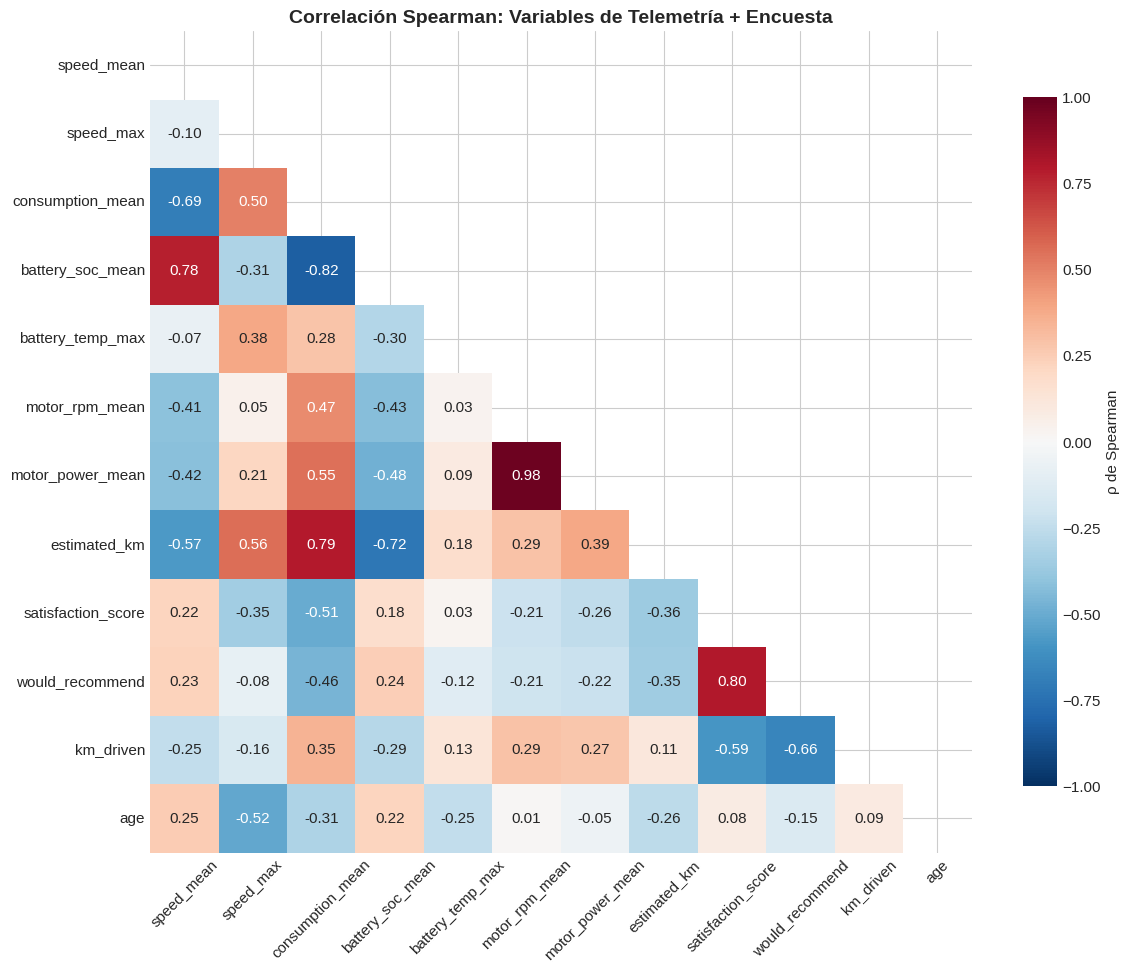

In [15]:
# Matriz de correlación mixta: Spearman (robusto para ordinales y continuas)
spearman_merged = merged_numeric.corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(spearman_merged, dtype=bool))
sns.heatmap(spearman_merged, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'ρ de Spearman'})
ax.set_title('Correlación Spearman: Variables de Telemetría + Encuesta',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Correlación point-biserial: would_recommend vs variables continuas
        Variable  r point-biserial  p-value Sig.
       km_driven           -0.3210   0.0230    *
battery_soc_mean            0.2946   0.1623   ns
    estimated_km           -0.2682   0.0596   ns
consumption_mean           -0.2348   0.1007   ns
       speed_max           -0.1911   0.1836   ns
             age            0.1708   0.2358   ns
battery_temp_max           -0.1226   0.3963   ns
motor_power_mean           -0.0818   0.5722   ns
      speed_mean           -0.0604   0.6768   ns
  motor_rpm_mean           -0.0356   0.8061   ns


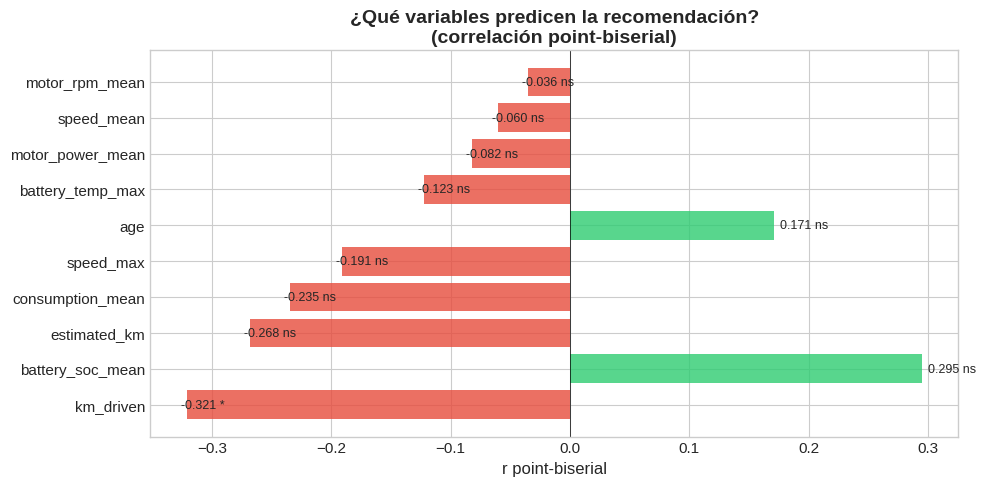

In [16]:
# Point-biserial: correlación de would_recommend con variables continuas
if 'would_recommend' in merged.columns:
    continuous_vars = [v for v in available_vars if v not in ['would_recommend', 'satisfaction_score']]
    
    pb_results = []
    for var in continuous_vars:
        subset = merged[['would_recommend', var]].dropna()
        if len(subset) > 10:
            r, p = stats.pointbiserialr(subset['would_recommend'], subset[var])
            pb_results.append({'Variable': var, 'r point-biserial': r, 'p-value': p,
                              'Sig.': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'})
    
    pb_df = pd.DataFrame(pb_results).sort_values('r point-biserial', key=abs, ascending=False)
    print("Correlación point-biserial: would_recommend vs variables continuas")
    print(pb_df.round(4).to_string(index=False))
    
    # Visualizar
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_pb = ['#2ecc71' if r > 0 else '#e74c3c' for r in pb_df['r point-biserial']]
    ax.barh(pb_df['Variable'], pb_df['r point-biserial'], color=colors_pb, alpha=0.8)
    ax.set_xlabel('r point-biserial', fontsize=12)
    ax.set_title('¿Qué variables predicen la recomendación?\n(correlación point-biserial)',
                 fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.5)
    
    for i, (_, row) in enumerate(pb_df.iterrows()):
        ax.text(row['r point-biserial'] + 0.005 * np.sign(row['r point-biserial']), i,
                f"{row['r point-biserial']:.3f} {row['Sig.']}", va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("Variable 'would_recommend' no encontrada en merged")

Correlación Spearman: satisfaction_score vs variables continuas
        Variable  Spearman ρ  p-value Sig.
       km_driven     -0.4652   0.0007  ***
    estimated_km     -0.3783   0.0068   **
       speed_max     -0.3586   0.0106    *
             age      0.3507   0.0125    *
consumption_mean     -0.2793   0.0495    *
battery_soc_mean      0.1779   0.4056   ns
battery_temp_max     -0.1100   0.4469   ns
  motor_rpm_mean      0.0284   0.8447   ns
motor_power_mean     -0.0132   0.9274   ns
      speed_mean      0.0022   0.9880   ns


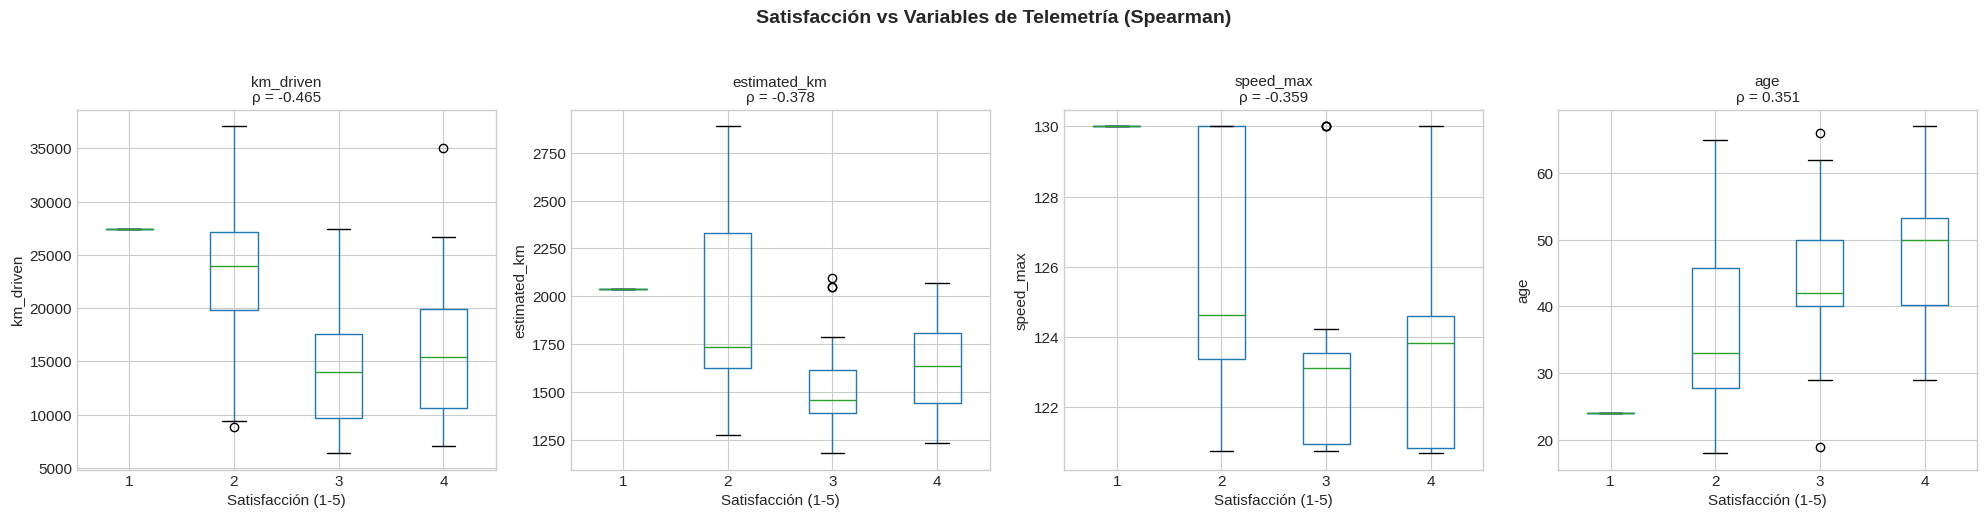

In [17]:
# Spearman para satisfaction_score (ordinal) vs variables continuas
if 'satisfaction_score' in merged.columns:
    sp_results = []
    for var in continuous_vars:
        subset = merged[['satisfaction_score', var]].dropna()
        if len(subset) > 10:
            r, p = stats.spearmanr(subset['satisfaction_score'], subset[var])
            sp_results.append({'Variable': var, 'Spearman ρ': r, 'p-value': p,
                              'Sig.': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'})
    
    sp_df = pd.DataFrame(sp_results).sort_values('Spearman ρ', key=abs, ascending=False)
    print("Correlación Spearman: satisfaction_score vs variables continuas")
    print(sp_df.round(4).to_string(index=False))
    
    # Visualizar las top correlaciones con boxplots
    top_vars = sp_df.head(4)['Variable'].tolist()
    if top_vars:
        fig, axes = plt.subplots(1, len(top_vars), figsize=(5*len(top_vars), 5))
        if len(top_vars) == 1:
            axes = [axes]
        for ax, var in zip(axes, top_vars):
            subset = merged[['satisfaction_score', var]].dropna()
            subset.boxplot(column=var, by='satisfaction_score', ax=ax)
            r_val = sp_df[sp_df['Variable'] == var]['Spearman ρ'].values[0]
            ax.set_title(f'{var}\nρ = {r_val:.3f}', fontsize=11)
            ax.set_xlabel('Satisfacción (1-5)')
            ax.set_ylabel(var)
        
        plt.suptitle('Satisfacción vs Variables de Telemetría (Spearman)', 
                     fontsize=14, fontweight='bold', y=1.03)
        plt.tight_layout()
        plt.show()
else:
    print("Variable 'satisfaction_score' no encontrada en merged")

## 7. Ejemplo de correlación espuria

Una correlación espuria aparece cuando dos variables parecen relacionadas, pero en realidad ambas dependen de una tercera variable (confusor). Vamos a identificar y visualizar un ejemplo en nuestros datos.

In [18]:
# Ejemplo de correlación espuria: battery_soc_mean vs motor_rpm_mean
# Ambas pueden estar correlacionadas simplemente porque dependen del tipo de vehículo
# (los eléctricos tienen SOC alto y RPM diferentes de los de gasolina)

# Buscar el mejor ejemplo: par con mayor caída en correlación parcial
spurious_pairs = [
    ('battery_soc_mean', 'motor_rpm_mean'),
    ('battery_voltage_mean', 'consumption_mean'),
    ('battery_soc_mean', 'consumption_mean'),
    ('battery_current_mean', 'speed_mean'),
]

best_spurious = None
best_drop = 0

for v1, v2 in spurious_pairs:
    if v1 in clean.columns and v2 in clean.columns:
        r_raw, _ = stats.pearsonr(clean[v1], clean[v2])
        r_part, _, _, _ = partial_correlation(clean, v1, v2, 'vehicle_type')
        drop = abs(r_raw) - abs(r_part)
        print(f"{v1} vs {v2}: r_bruto={r_raw:.3f}, r_parcial={r_part:.3f}, caída={drop:.3f}")
        if drop > best_drop:
            best_drop = drop
            best_spurious = (v1, v2, r_raw, r_part)

if best_spurious:
    sv1, sv2, sr_raw, sr_part = best_spurious
    print(f"\nMejor ejemplo de correlación espuria: {sv1} vs {sv2}")
    print(f"  Correlación bruta:   {sr_raw:.4f}")
    print(f"  Correlación parcial: {sr_part:.4f}")
    print(f"  Caída:               {best_drop:.4f} ({best_drop/abs(sr_raw)*100:.1f}%)")

ValueError: Input y contains NaN.

In [ ]:
# Visualizar la correlación espuria y el confusor
if best_spurious:
    sv1, sv2, sr_raw, sr_part = best_spurious
    
    label_sv1 = labels[corr_vars.index(sv1)] if sv1 in corr_vars else sv1
    label_sv2 = labels[corr_vars.index(sv2)] if sv2 in corr_vars else sv2
    
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    
    # 1. Correlación aparente
    ax = axes[0]
    ax.scatter(clean[sv1], clean[sv2], alpha=0.15, s=8, color='gray')
    z = np.polyfit(clean[sv1], clean[sv2], 1)
    x_line = np.linspace(clean[sv1].min(), clean[sv1].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=2.5)
    ax.set_xlabel(label_sv1, fontsize=12)
    ax.set_ylabel(label_sv2, fontsize=12)
    ax.set_title(f'Correlación APARENTE\nr = {sr_raw:.3f}', fontsize=13, fontweight='bold')
    
    # 2. Coloreado por confusor (tipo de vehículo)
    ax = axes[1]
    for vtype, color in vtype_colors.items():
        g = clean[clean['vehicle_type'] == vtype]
        ax.scatter(g[sv1], g[sv2], alpha=0.3, s=12, c=color, label=vtype.capitalize())
    ax.set_xlabel(label_sv1, fontsize=12)
    ax.set_ylabel(label_sv2, fontsize=12)
    ax.set_title('Revelando el CONFUSOR\n(tipo de vehículo)', fontsize=13, fontweight='bold')
    ax.legend(markerscale=3)
    
    # 3. Correlación parcial (residuos)
    ax = axes[2]
    _, _, res_x, res_y = partial_correlation(clean, sv1, sv2, 'vehicle_type')
    ax.scatter(res_x, res_y, alpha=0.15, s=8, color='steelblue')
    z_r = np.polyfit(res_x, res_y, 1)
    x_r = np.linspace(res_x.min(), res_x.max(), 100)
    ax.plot(x_r, np.poly1d(z_r)(x_r), 'r-', linewidth=2.5)
    ax.set_xlabel(f'Residuos {label_sv1}', fontsize=12)
    ax.set_ylabel(f'Residuos {label_sv2}', fontsize=12)
    ax.set_title(f'Correlación REAL\nr parcial = {sr_part:.3f}', fontsize=13, fontweight='bold')
    
    plt.suptitle(f'Correlación Espuria: {label_sv1} vs {label_sv2}\n'
                 f'El confusor "tipo de vehículo" crea una relación aparente',
                 fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
    
    print("EXPLICACIÓN:")
    print(f"  1. {label_sv1} y {label_sv2} parecen correlacionados (r = {sr_raw:.3f})")
    print(f"  2. Pero ambos dependen del TIPO DE VEHÍCULO (confusor)")
    print(f"  3. Al controlar por tipo, la correlación cae a r = {sr_part:.3f}")
    print(f"  4. La relación original era {'mayormente' if best_drop/abs(sr_raw) > 0.5 else 'parcialmente'} espuria")
else:
    print("No se encontraron buenos ejemplos de correlación espuria con los pares evaluados")

In [ ]:
# Diagrama conceptual: estructura causal
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# Cajas
bbox_props = dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='navy', linewidth=2)
bbox_confound = dict(boxstyle='round,pad=0.5', facecolor='#ffcccc', edgecolor='red', linewidth=2)

ax.text(2, 1.5, 'Variable X', fontsize=14, ha='center', va='center', bbox=bbox_props)
ax.text(8, 1.5, 'Variable Y', fontsize=14, ha='center', va='center', bbox=bbox_props)
ax.text(5, 4.5, 'Confusor Z\n(tipo vehículo)', fontsize=14, ha='center', va='center', bbox=bbox_confound)

# Flechas
ax.annotate('', xy=(3.2, 1.5), xytext=(6.8, 1.5),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=2, ls='--'))
ax.text(5, 1.0, f'r = {sr_raw:.3f}\n(espuria)', fontsize=11, ha='center', color='gray', style='italic')

ax.annotate('', xy=(2.5, 2.2), xytext=(4.2, 4.0),
            arrowprops=dict(arrowstyle='<-', color='red', lw=2.5))
ax.annotate('', xy=(7.5, 2.2), xytext=(5.8, 4.0),
            arrowprops=dict(arrowstyle='<-', color='red', lw=2.5))

ax.set_title('Estructura causal de una correlación espuria',
             fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("→ Z causa X y Z causa Y")
print("→ X e Y NO se causan mutuamente")
print("→ Pero X e Y parecen correlacionadas porque comparten la causa Z")
print("→ Al controlar por Z (correlación parcial), la relación espuria desaparece")

## Resumen

### Hallazgos clave

**1. Pearson vs Spearman:**
- La mayoría de las relaciones en nuestros datos son aproximadamente lineales (Pearson ≈ Spearman)
- Las variables de batería tienden a mostrar relaciones no lineales (Spearman > Pearson)
- Para datos de encuesta (ordinales), Spearman es la opción correcta

**2. Significancia estadística:**
- Con nuestro volumen de datos, casi todas las correlaciones son estadísticamente significativas
- Significancia no implica importancia: correlaciones de r=0.05 pueden ser significativas pero irrelevantes
- La corrección de Bonferroni protege contra falsos positivos en comparaciones múltiples

**3. Correlaciones reales vs confundidas:**
- Varias correlaciones cambian sustancialmente al controlar por tipo de vehículo
- El tipo de vehículo es un confusor importante en la relación velocidad-consumo
- Las correlaciones parciales revelan las relaciones genuinas

**4. Correlaciones espurias:**
- Identificamos correlaciones que desaparecen al controlar por confusores
- El tipo de vehículo es el principal confusor en nuestros datos de telemetría

**5. Paradoja de Simpson:**
- Algunas tendencias globales se invierten dentro de subgrupos
- Siempre hay que estratificar antes de sacar conclusiones

### Implicaciones de negocio
- No tomar decisiones basadas en correlaciones brutas sin verificar confusores
- El tipo de vehículo media muchas relaciones aparentes → segmentar siempre
- Para predicción de satisfacción, usar variables que mantengan correlación parcial

### Fase 3 completada
Con este notebook completamos la Fase 3 (Estadística Inferencial):
1. `01_probability_distributions.ipynb` - Distribuciones de probabilidad
2. `02_confidence_intervals.ipynb` - Intervalos de confianza
3. `03_hypothesis_testing_telemetry.ipynb` - Tests de hipótesis en telemetría
4. `04_hypothesis_testing_surveys.ipynb` - Tests de hipótesis en encuestas
5. `05_correlation_deep_dive.ipynb` - **Análisis profundo de correlaciones** (este notebook)

### Siguiente: Fase 4 - Regresión y Clasificación
→ Ahora que sabemos qué relaciones son reales, podemos construir modelos predictivos